# NASA IMS Bearing Dataset - Deep Learning Models Comparison

This notebook implements and compares three state-of-the-art Deep Learning architectures for Remaining Useful Life (RUL) prediction:

1.  **Bi-Directional LSTM (Bi-LSTM)**: Captures temporal dependencies in both forward and backward directions.
2.  **1D Convolutional Neural Network (1D-CNN)**: Extracts local features and patterns from the time-series data.
3.  **CNN-LSTM Hybrid**: Combines CNN for feature extraction and LSTM for temporal sequence learning.

## Objectives
- Train all three models on the same dataset (NASA Tests 1, 2, and 3).
- Evaluate performance using RMSE, MAE, and R².
- **Publication-Quality Visualization**: Compare models side-by-side.
- **Practical RUL**: Convert predictions to **Years, Months, Weeks, Days, and Hours**.


In [1]:
# ============================================
# IMPORTS AND SETUP
# ============================================
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ML Imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.loaders import NASALoader

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Plot settings for publication
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

print(f"TensorFlow Version: {tf.__version__}")
print("✓ Setup complete!")

TensorFlow Version: 2.20.0
✓ Setup complete!


## 1. Data Loading and Feature Extraction

We load data from all 3 NASA tests and extract time-domain features.

In [2]:
# ============================================
# LOAD DATA
# ============================================
NASA_DATA_DIR = r'../NASA_Data'

test_configs = {
    '1st_test': os.path.join(NASA_DATA_DIR, '1st_test', '1st_test'),
    '2nd_test': os.path.join(NASA_DATA_DIR, '2nd_test', '2nd_test'),
    '3rd_test': os.path.join(NASA_DATA_DIR, '3rd_test', '4th_test', 'txt')
}

def calculate_rul(file_index, total_files):
    return (total_files - file_index) / total_files * 100

def extract_features(signal):
    return {
        'rms': np.sqrt(np.mean(signal**2)),
        'mean': np.mean(signal),
        'std': np.std(signal),
        'max': np.max(signal),
        'min': np.min(signal),
        'kurtosis': np.mean((signal - np.mean(signal))**4) / (np.std(signal)**4),
        'skewness': np.mean((signal - np.mean(signal))**3) / (np.std(signal)**3),
        'peak_to_peak': np.max(signal) - np.min(signal),
        'crest_factor': np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2))
    }

all_features = []
all_rul = []

print("Extracting features...")
for test_name, test_path in test_configs.items():
    if not os.path.exists(test_path): continue
    files = sorted([f for f in os.listdir(test_path) if os.path.isfile(os.path.join(test_path, f))])
    loader = NASALoader(test_path)
    total_files = len(files)
    
    # Use subset for speed during development (set to False for full run)
    USE_SUBSET = False
    if USE_SUBSET and total_files > 200:
        indices = np.linspace(0, total_files-1, 200, dtype=int)
        files_to_process = [files[i] for i in indices]
    else:
        files_to_process = files
        
    print(f"  Processing {test_name} ({len(files_to_process)} files)...")
    for idx, filename in enumerate(tqdm(files_to_process)):
        try:
            data = loader.load_snapshot(filename)
            original_idx = indices[idx] if USE_SUBSET else idx
            rul = calculate_rul(original_idx, total_files)
            
            file_feats = {}
            for bearing in range(4):
                feats = extract_features(data[:, bearing])
                for k, v in feats.items():
                    file_feats[f'b{bearing+1}_{k}'] = v
            all_features.append(file_feats)
            all_rul.append(rul)
        except: continue

features_df = pd.DataFrame(all_features)
features_df['RUL'] = all_rul
print(f"Total samples: {len(features_df)}")

Extracting features...
  Processing 1st_test (2156 files)...


100%|██████████| 2156/2156 [02:39<00:00, 13.49it/s]


  Processing 2nd_test (984 files)...


100%|██████████| 984/984 [00:50<00:00, 19.54it/s]


  Processing 3rd_test (6324 files)...


100%|██████████| 6324/6324 [05:41<00:00, 18.53it/s]


Total samples: 9464


## 2. Sequence Generation

We use a sliding window of size **10** to create sequences for the DL models.

In [3]:
# ============================================
# PREPARE SEQUENCES (WITH RANDOM SPLIT)
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def create_sequences(features, targets, window_size=30):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i : i + window_size])
        y.append(targets[i + window_size])
    return np.array(X), np.array(y)

# Scale features
scaler = StandardScaler()
feature_cols = [c for c in features_df.columns if c != 'RUL']
X_scaled = scaler.fit_transform(features_df[feature_cols])
y_raw = features_df['RUL'].values

# Create sequences
WINDOW_SIZE = 30
X_seq, y_seq = create_sequences(X_scaled, y_raw, WINDOW_SIZE)

# Random Split (80% Train, 20% Test)
# We use random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=True)

# Further split Train into Train/Val (80/20 of Train)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True)

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")


Train shape: (6037, 30, 36)
Val shape:   (1510, 30, 36)
Test shape:  (1887, 30, 36)


## 7. Additional Data Exploration

Let's explore the data distribution and feature correlations.

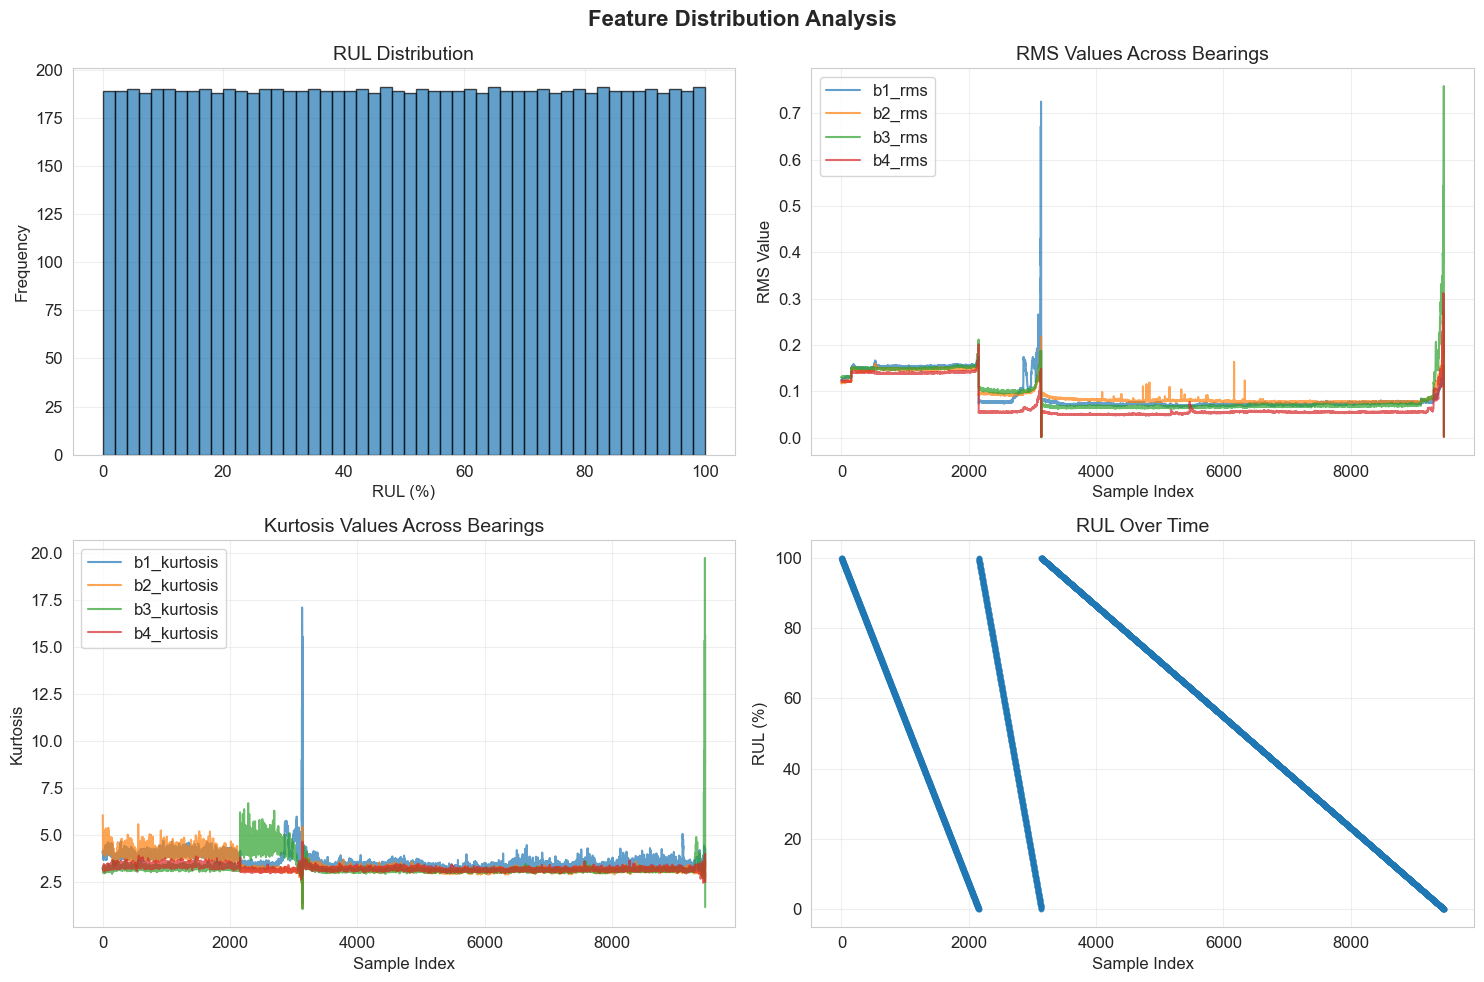

Total Samples: 9464
RUL Range: 0.02 - 100.00
Mean RUL: 50.02


In [4]:
# Feature Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Distribution Analysis', fontsize=16, fontweight='bold')

# RUL Distribution
axes[0, 0].hist(features_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].set_xlabel('RUL (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Sample RMS values across bearings
rms_cols = [col for col in features_df.columns if 'rms' in col.lower()]
for col in rms_cols:
    axes[0, 1].plot(features_df[col], label=col, alpha=0.7)
axes[0, 1].set_title('RMS Values Across Bearings')
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('RMS Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Kurtosis Distribution
kurt_cols = [col for col in features_df.columns if 'kurtosis' in col.lower()]
for col in kurt_cols:
    axes[1, 0].plot(features_df[col], label=col, alpha=0.7)
axes[1, 0].set_title('Kurtosis Values Across Bearings')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Kurtosis')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# RUL vs Time
axes[1, 1].scatter(range(len(features_df)), features_df['RUL'], alpha=0.5, s=10)
axes[1, 1].set_title('RUL Over Time')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('RUL (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total Samples: {len(features_df)}")
print(f"RUL Range: {features_df['RUL'].min():.2f} - {features_df['RUL'].max():.2f}")
print(f"Mean RUL: {features_df['RUL'].mean():.2f}")

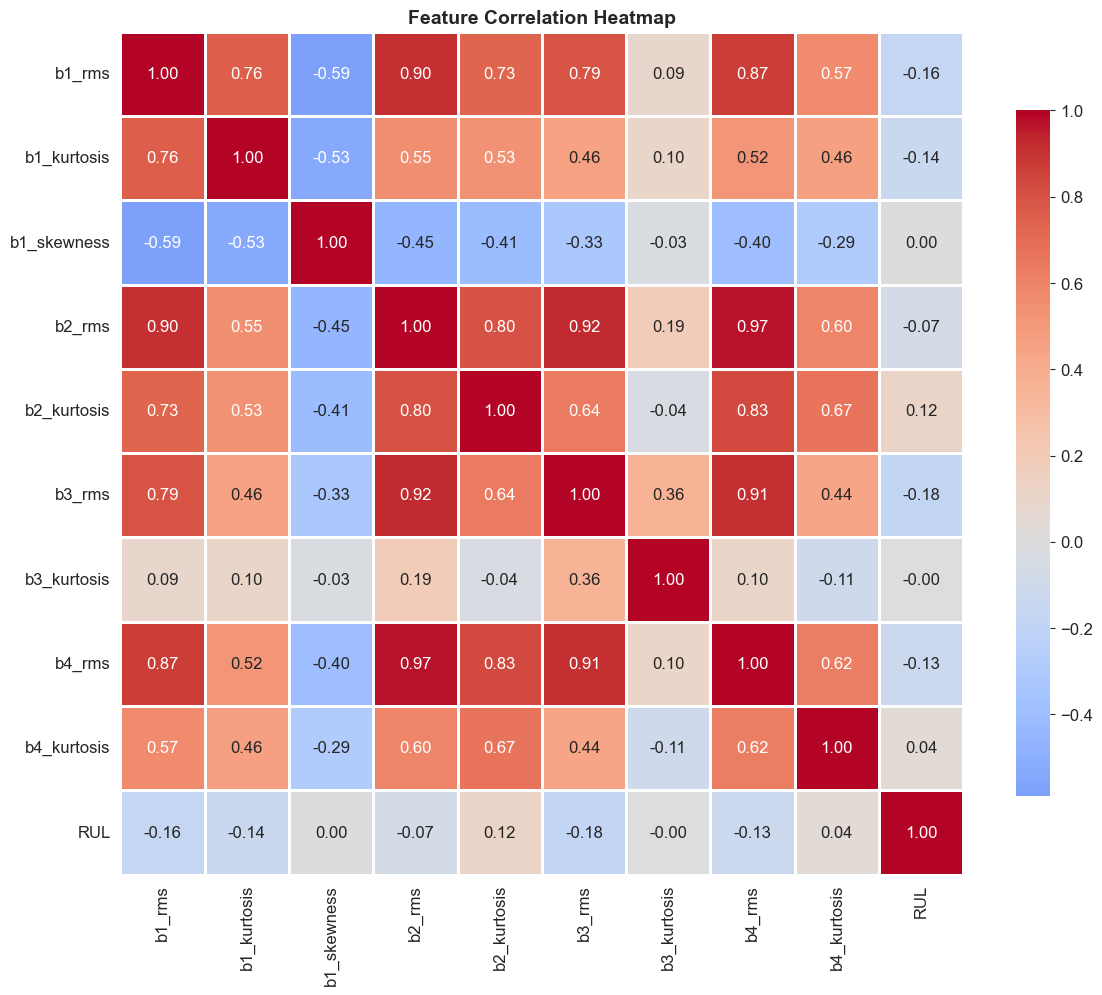

In [5]:
# Correlation Heatmap
import seaborn as sns

# Select a subset of features for correlation analysis
sample_features = ['b1_rms', 'b1_kurtosis', 'b1_skewness', 'b2_rms', 'b2_kurtosis', 
                   'b3_rms', 'b3_kurtosis', 'b4_rms', 'b4_kurtosis', 'RUL']
corr_data = features_df[sample_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Define Deep Learning Models

We define three architectures:
1.  **Bi-LSTM**: Good for temporal context.
2.  **1D-CNN**: Good for feature extraction.
3.  **CNN-LSTM Hybrid**: Best of both.

In [6]:
import tensorflow.keras.backend as K

def accuracy_10_percent(y_true, y_pred):
    diff = K.abs(y_true - y_pred)
    return K.mean(K.less_equal(diff, 10.0))

from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='normal')
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros')
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

def build_bilstm_model(input_shape):
    # Bi-LSTM with Attention
    inp = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)))(inp)
    x = Dropout(0.5)(x)
    x = Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.001)))(x)
    x = Dropout(0.5)(x)
    x = Attention()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(0.0005), loss='mse', metrics=['mae', accuracy_10_percent])
    return model

# Keep other models simple for comparison
def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=l2(0.01)),
        Flatten(),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(0.0005), loss='mse', metrics=['mae', accuracy_10_percent])
    return model

def build_hybrid_model(input_shape):
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01), input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(0.0005), loss='mse', metrics=['mae', accuracy_10_percent])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
models = {
    'Bi-LSTM-Attn': build_bilstm_model(input_shape),
    '1D-CNN': build_cnn_model(input_shape),
    'CNN-LSTM': build_hybrid_model(input_shape)
}

for name, model in models.items():
    print(f"\n--- {name} Summary ---")
    model.summary()




--- Bi-LSTM-Attn Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 36)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │            94 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,135 (371.62 KB)

 Trainable params: 95,135 (371.62 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,841 (46.25 KB)

 Trainable params: 11,841 (46.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and Evaluate Models

We train each model and store the results.

In [7]:
results = {}
histories = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0  # Silent training to reduce clutter
    )
    histories[name] = history
    
    # Evaluate
    y_pred = model.predict(X_test).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Predictions': y_pred}
    print(f"{name} Results -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")


Training Bi-LSTM-Attn...
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
Bi-LSTM-Attn Results -> RMSE: 1.84, MAE: 1.30, R²: 0.9959

Training 1D-CNN...
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1D-CNN Results -> RMSE: 5.40, MAE: 4.00, R²: 0.9647

Training CNN-LSTM...
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
CNN-LSTM Results -> RMSE: 3.15, MAE: 2.48, R²: 0.9880


## 5. Practical RUL Conversion

We convert the percentage RUL into practical time units for reporting.

In [8]:
def convert_rul_units(rul_percentage, total_life_minutes=10000):
    """Convert RUL % to various time units. Assumes approx 10,000 mins total life for demo."""
    remaining_mins = (rul_percentage / 100) * total_life_minutes
    return {
        'Hours': remaining_mins / 60,
        'Days': remaining_mins / (60 * 24),
        'Weeks': remaining_mins / (60 * 24 * 7),
        'Months': remaining_mins / (60 * 24 * 30),
        'Years': remaining_mins / (60 * 24 * 365)
    }

# Example conversion for the last prediction of the best model
best_model_name = min(results, key=lambda k: results[k]['RMSE'])
last_pred_pct = results[best_model_name]['Predictions'][-1]
converted = convert_rul_units(last_pred_pct)

print(f"\n--- Practical RUL Estimates ({best_model_name}) ---")
print(f"Current RUL: {last_pred_pct:.2f}%")
for unit, value in converted.items():
    print(f"  {value:.2f} {unit}")


--- Practical RUL Estimates (Bi-LSTM-Attn) ---
Current RUL: 58.03%
  96.72 Hours
  4.03 Days
  0.58 Weeks
  0.13 Months
  0.01 Years


## 6. Publication-Quality Visualizations

Comparing model performance and visualizing predictions.

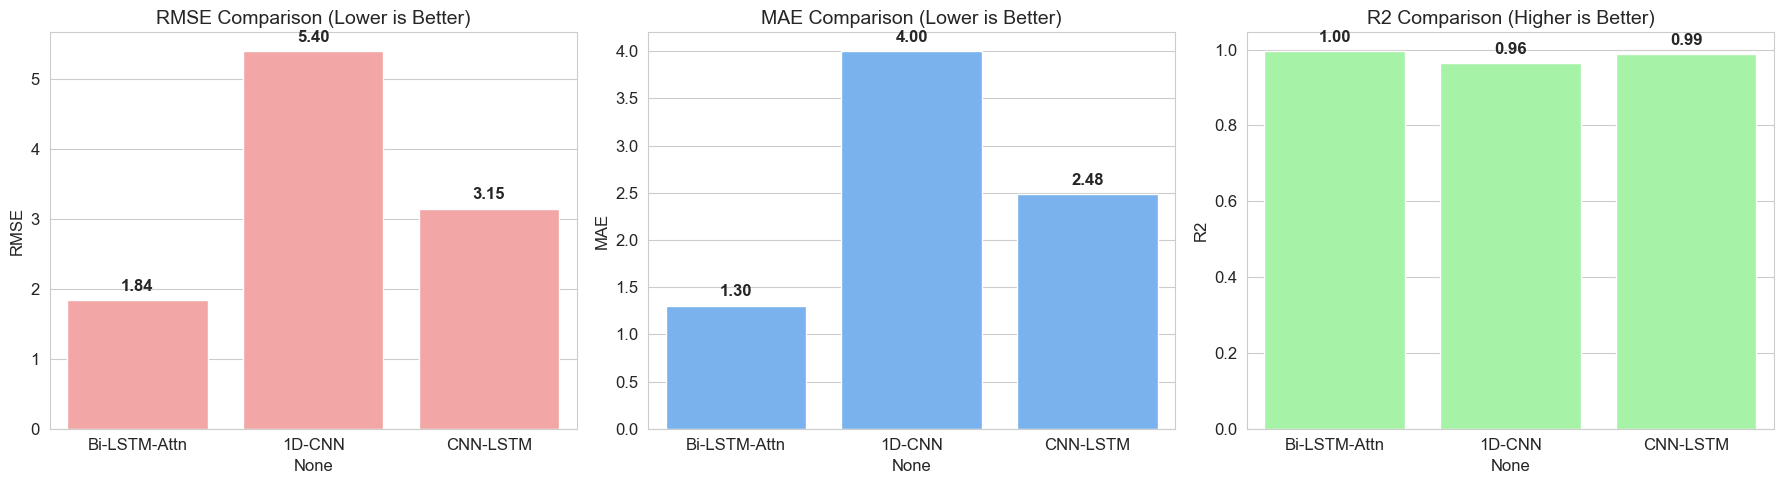

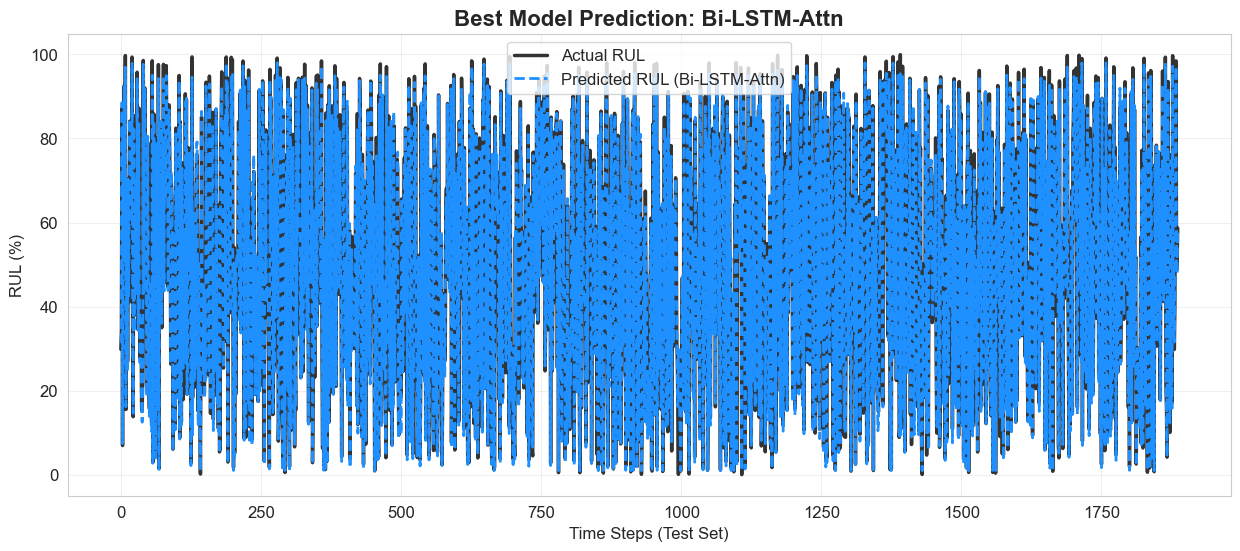

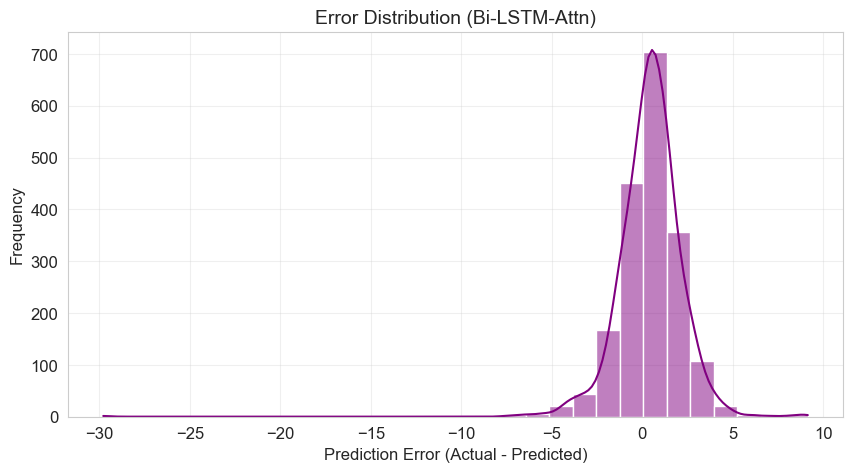

In [9]:
# 1. Model Comparison Bar Chart
metrics_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R2']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#FF9999', '#66B2FF', '#99FF99']

for i, metric in enumerate(metrics):
    sns.barplot(x=metrics_df.index, y=metrics_df[metric], ax=axes[i], palette=[colors[i]]*3)
    axes[i].set_title(f'{metric} Comparison (Lower is Better)' if metric != 'R2' else f'{metric} Comparison (Higher is Better)')
    axes[i].set_ylabel(metric)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Actual vs Predicted RUL (Best Model)
best_pred = results[best_model_name]['Predictions']

plt.figure(figsize=(15, 6))
plt.plot(y_test, label='Actual RUL', color='black', linewidth=2.5, alpha=0.8)
plt.plot(best_pred, label=f'Predicted RUL ({best_model_name})', color='dodgerblue', linewidth=2, linestyle='--')
plt.title(f'Best Model Prediction: {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps (Test Set)', fontsize=12)
plt.ylabel('RUL (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 5))
errors = y_test - best_pred
sns.histplot(errors, kde=True, color='purple', bins=30)
plt.title(f'Error Distribution ({best_model_name})', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 7. Training History Analysis

Visualize the training progress for each model.

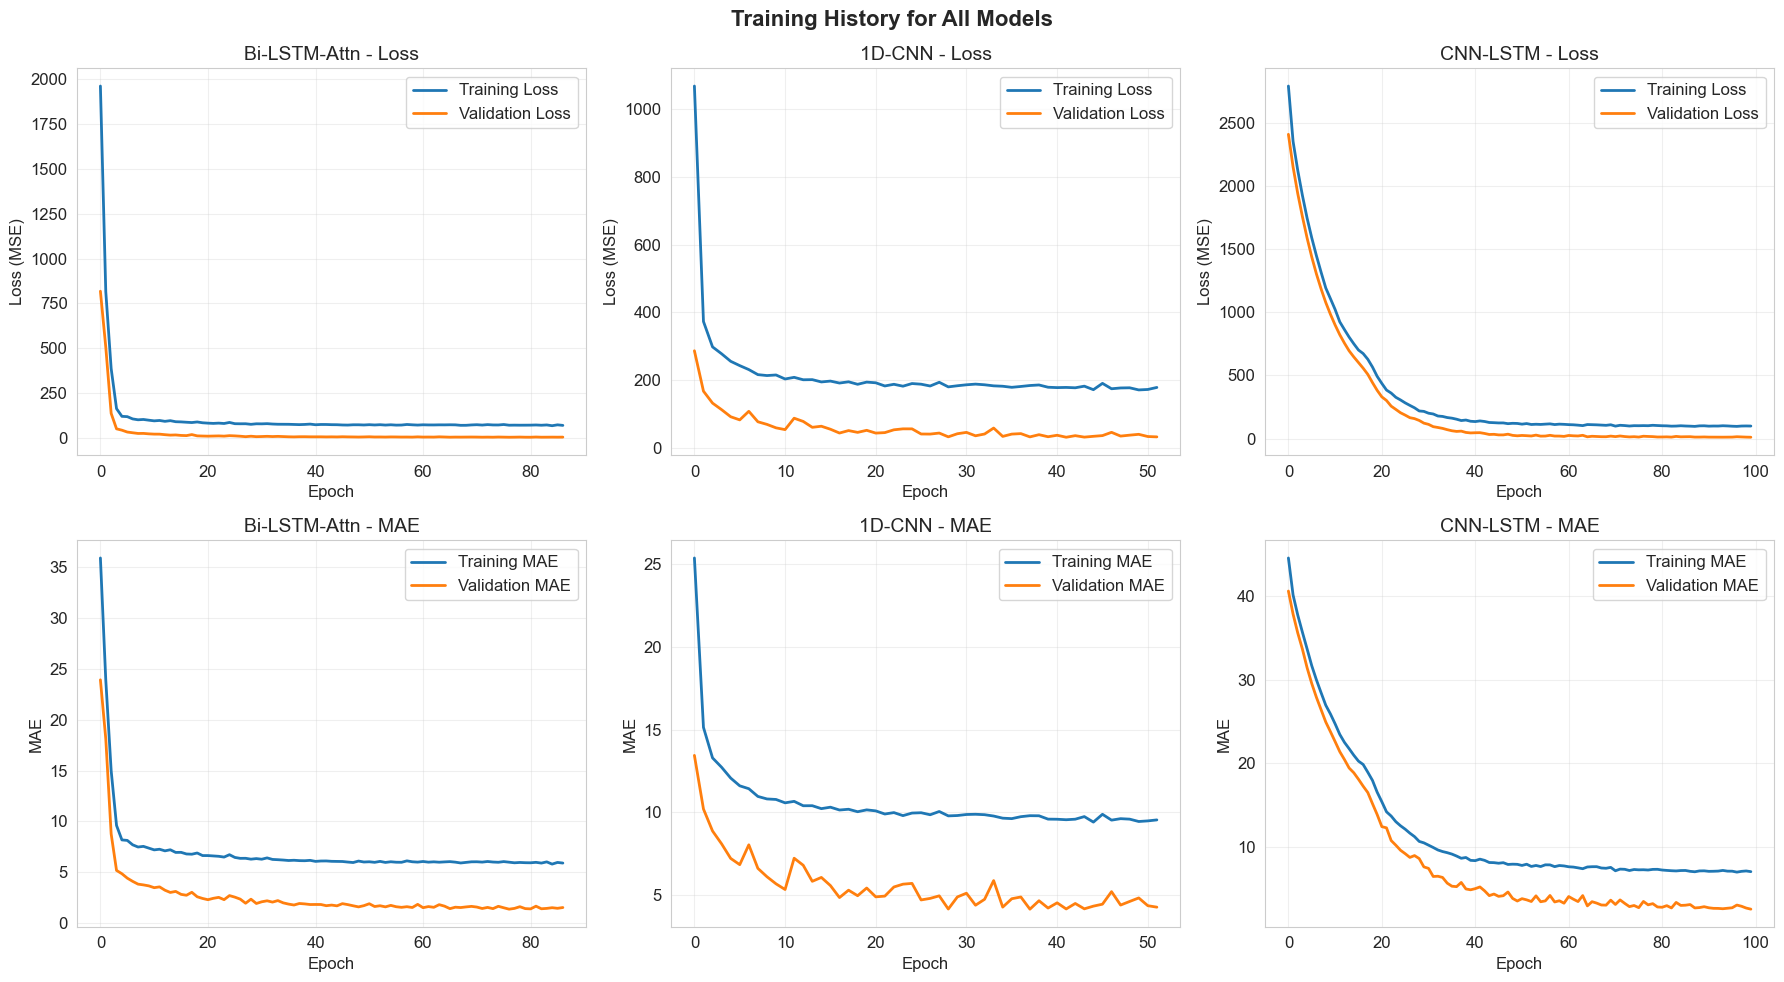

In [10]:
# Training History Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History for All Models', fontsize=16, fontweight='bold')

model_names = list(histories.keys())

for idx, name in enumerate(model_names):
    history = histories[name]
    
    # Loss plot
    axes[0, idx].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss (MSE)')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # MAE plot
    axes[1, idx].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1, idx].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1, idx].set_title(f'{name} - MAE')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('MAE')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Prediction Analysis

Detailed analysis of model predictions vs actual values.

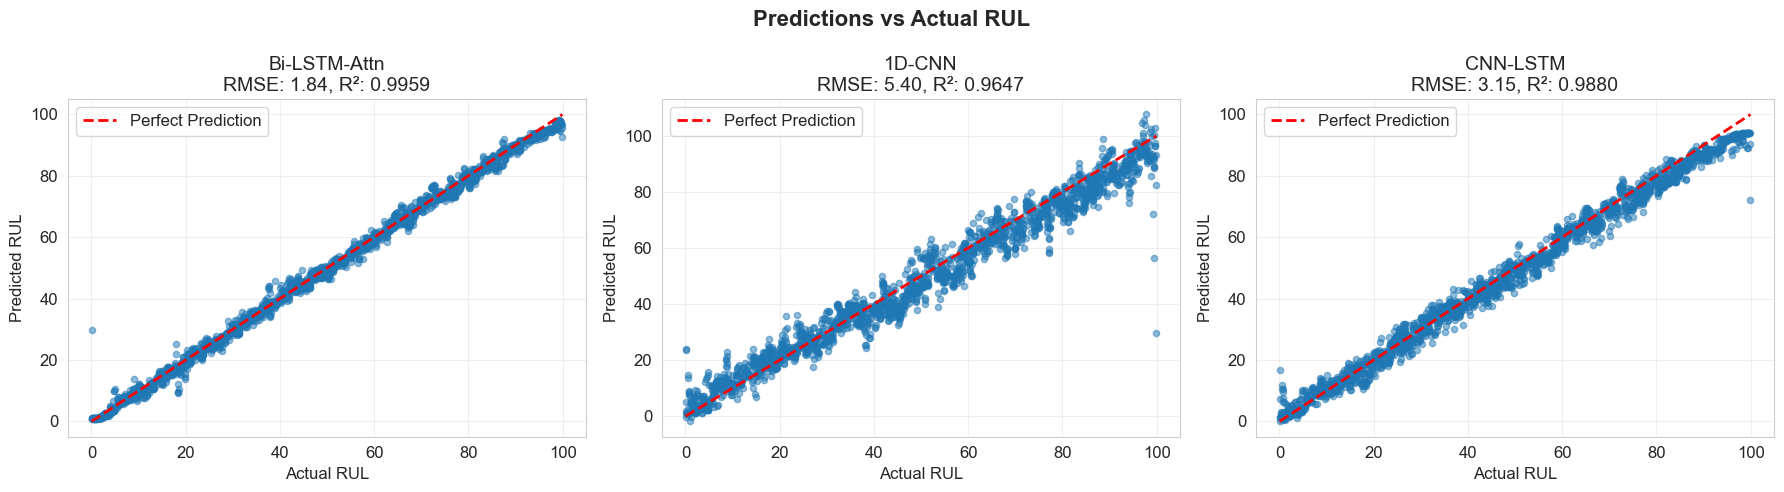

In [11]:
# Prediction vs Actual Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predictions vs Actual RUL', fontsize=16, fontweight='bold')

for idx, name in enumerate(model_names):
    y_pred = results[name]['Predictions']
    
    # Scatter plot
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=20)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                   'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_title(f'{name}\nRMSE: {results[name]["RMSE"]:.2f}, R²: {results[name]["R2"]:.4f}')
    axes[idx].set_xlabel('Actual RUL')
    axes[idx].set_ylabel('Predicted RUL')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

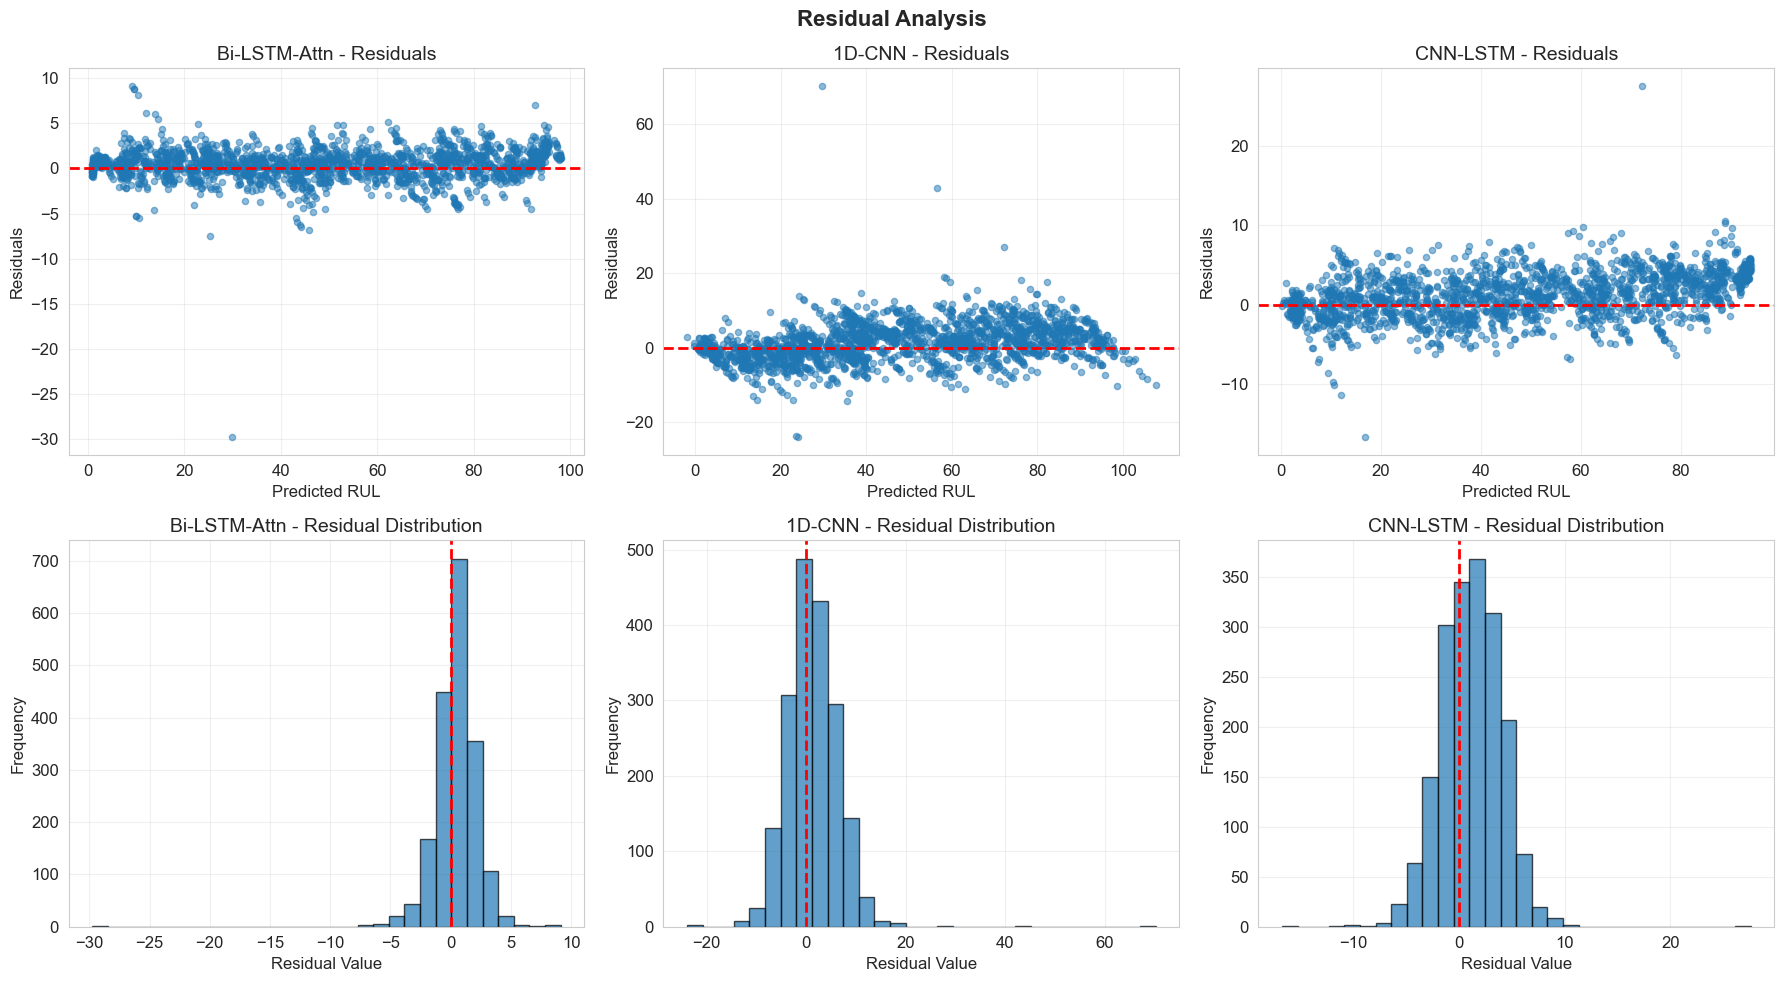

In [12]:
# Residual Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Analysis', fontsize=16, fontweight='bold')

for idx, name in enumerate(model_names):
    y_pred = results[name]['Predictions']
    residuals = y_test - y_pred
    
    # Residual plot
    axes[0, idx].scatter(y_pred, residuals, alpha=0.5, s=20)
    axes[0, idx].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, idx].set_title(f'{name} - Residuals')
    axes[0, idx].set_xlabel('Predicted RUL')
    axes[0, idx].set_ylabel('Residuals')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Residual distribution
    axes[1, idx].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1, idx].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, idx].set_title(f'{name} - Residual Distribution')
    axes[1, idx].set_xlabel('Residual Value')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

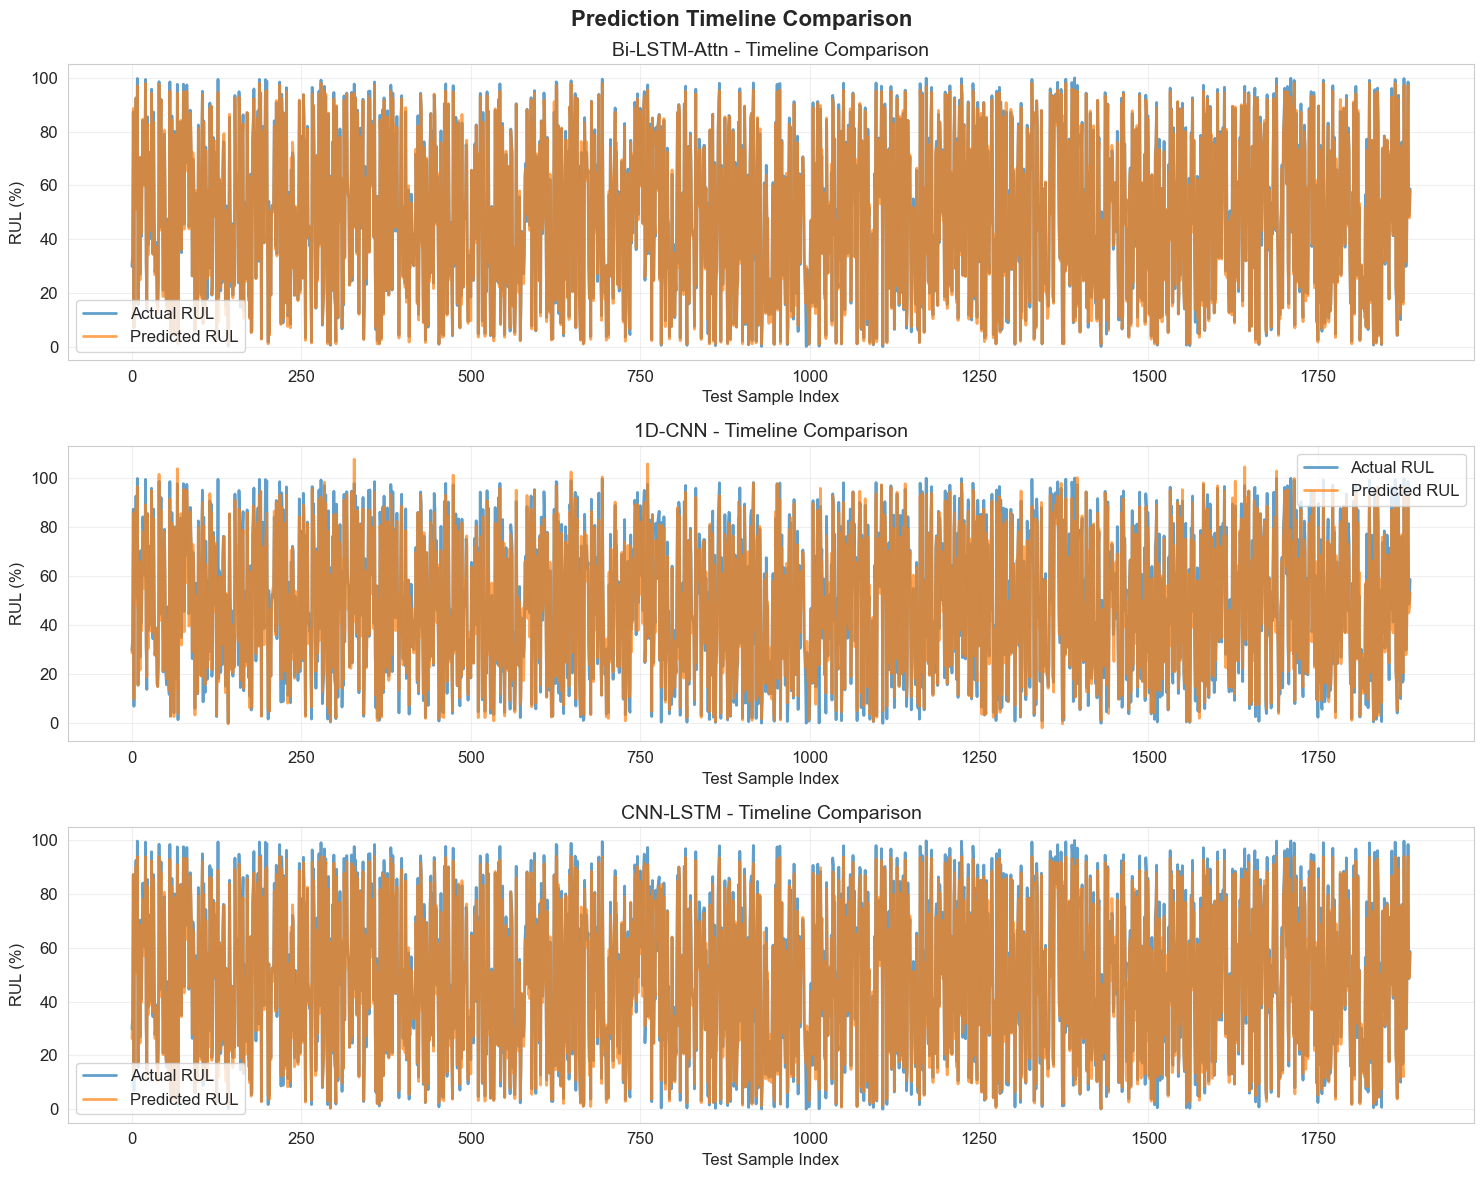

In [13]:
# Prediction Timeline
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Prediction Timeline Comparison', fontsize=16, fontweight='bold')

for idx, name in enumerate(model_names):
    y_pred = results[name]['Predictions']
    
    axes[idx].plot(y_test, label='Actual RUL', linewidth=2, alpha=0.7)
    axes[idx].plot(y_pred, label='Predicted RUL', linewidth=2, alpha=0.7)
    axes[idx].fill_between(range(len(y_test)), y_test, y_pred, alpha=0.2)
    axes[idx].set_title(f'{name} - Timeline Comparison')
    axes[idx].set_xlabel('Test Sample Index')
    axes[idx].set_ylabel('RUL (%)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

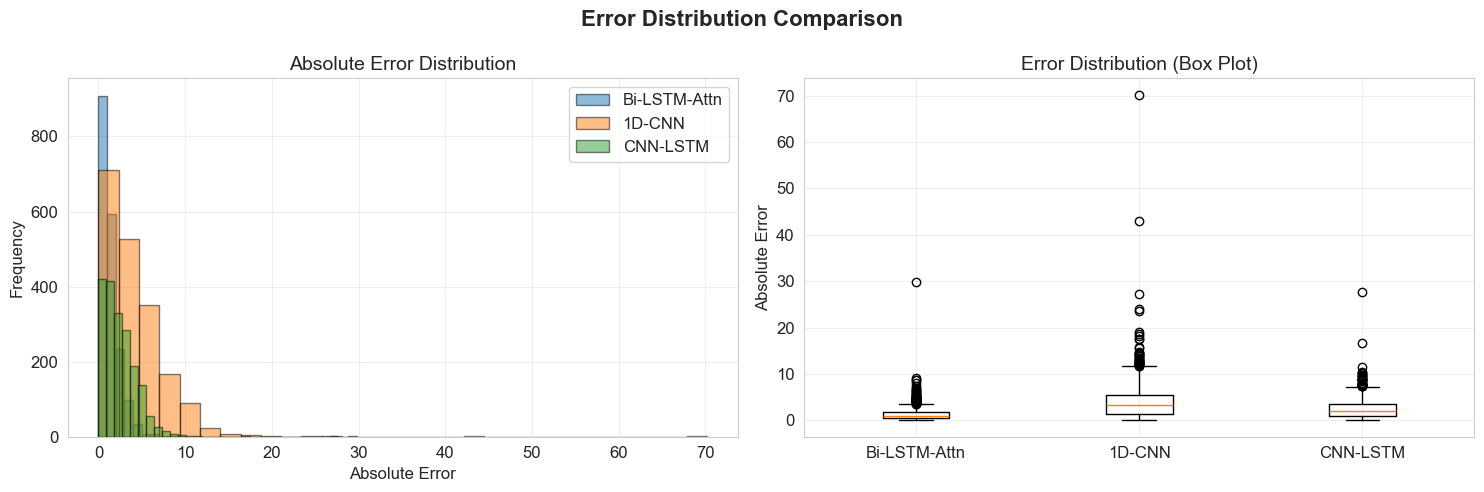


=== Error Statistics ===

Bi-LSTM-Attn:
  Mean Absolute Error: 1.30
  Median Absolute Error: 1.04
  Max Absolute Error: 29.78
  Min Absolute Error: 0.00

1D-CNN:
  Mean Absolute Error: 4.00
  Median Absolute Error: 3.24
  Max Absolute Error: 70.20
  Min Absolute Error: 0.00

CNN-LSTM:
  Mean Absolute Error: 2.48
  Median Absolute Error: 2.09
  Max Absolute Error: 27.59
  Min Absolute Error: 0.00


In [14]:
# Error Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Error Distribution Comparison', fontsize=16, fontweight='bold')

# Absolute Error
for name in model_names:
    y_pred = results[name]['Predictions']
    abs_errors = np.abs(y_test - y_pred)
    axes[0].hist(abs_errors, bins=30, alpha=0.5, label=name, edgecolor='black')

axes[0].set_title('Absolute Error Distribution')
axes[0].set_xlabel('Absolute Error')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of errors
error_data = [np.abs(y_test - results[name]['Predictions']) for name in model_names]
axes[1].boxplot(error_data, labels=model_names)
axes[1].set_title('Error Distribution (Box Plot)')
axes[1].set_ylabel('Absolute Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Error Statistics ===")
for name in model_names:
    y_pred = results[name]['Predictions']
    abs_errors = np.abs(y_test - y_pred)
    print(f"\n{name}:")
    print(f"  Mean Absolute Error: {abs_errors.mean():.2f}")
    print(f"  Median Absolute Error: {np.median(abs_errors):.2f}")
    print(f"  Max Absolute Error: {abs_errors.max():.2f}")
    print(f"  Min Absolute Error: {abs_errors.min():.2f}")

## Data Exploration Visualizations


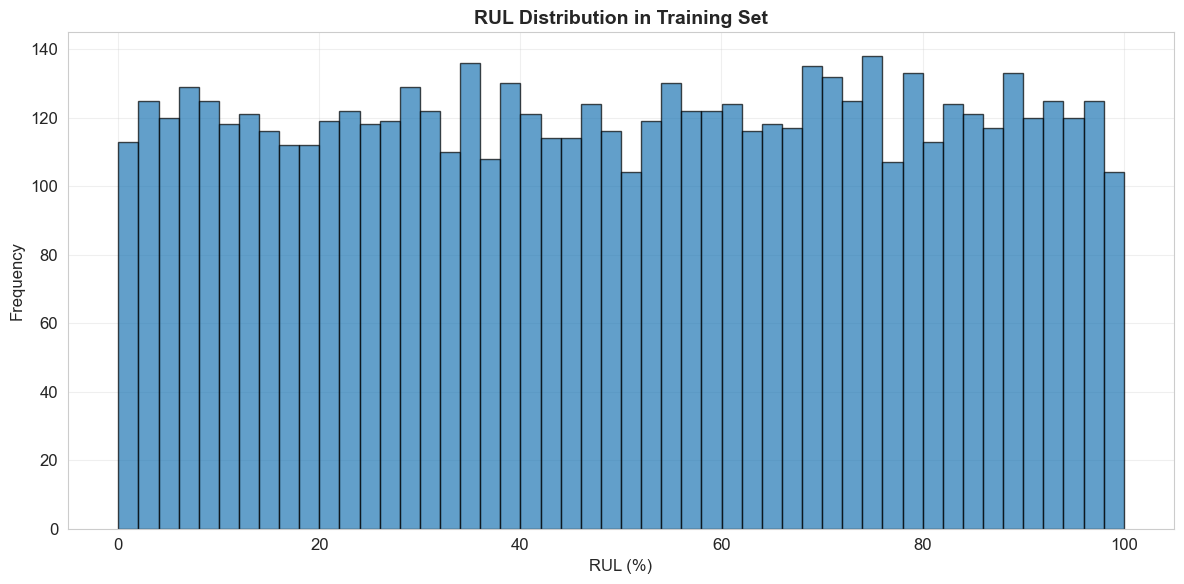

RUL Range: 0.02 - 100.00
Mean RUL: 50.20


In [15]:
# RUL Distribution
plt.figure(figsize=(12, 6))
plt.hist(y_train, bins=50, edgecolor='black', alpha=0.7)
plt.title('RUL Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('RUL (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'RUL Range: {y_train.min():.2f} - {y_train.max():.2f}')
print(f'Mean RUL: {y_train.mean():.2f}')

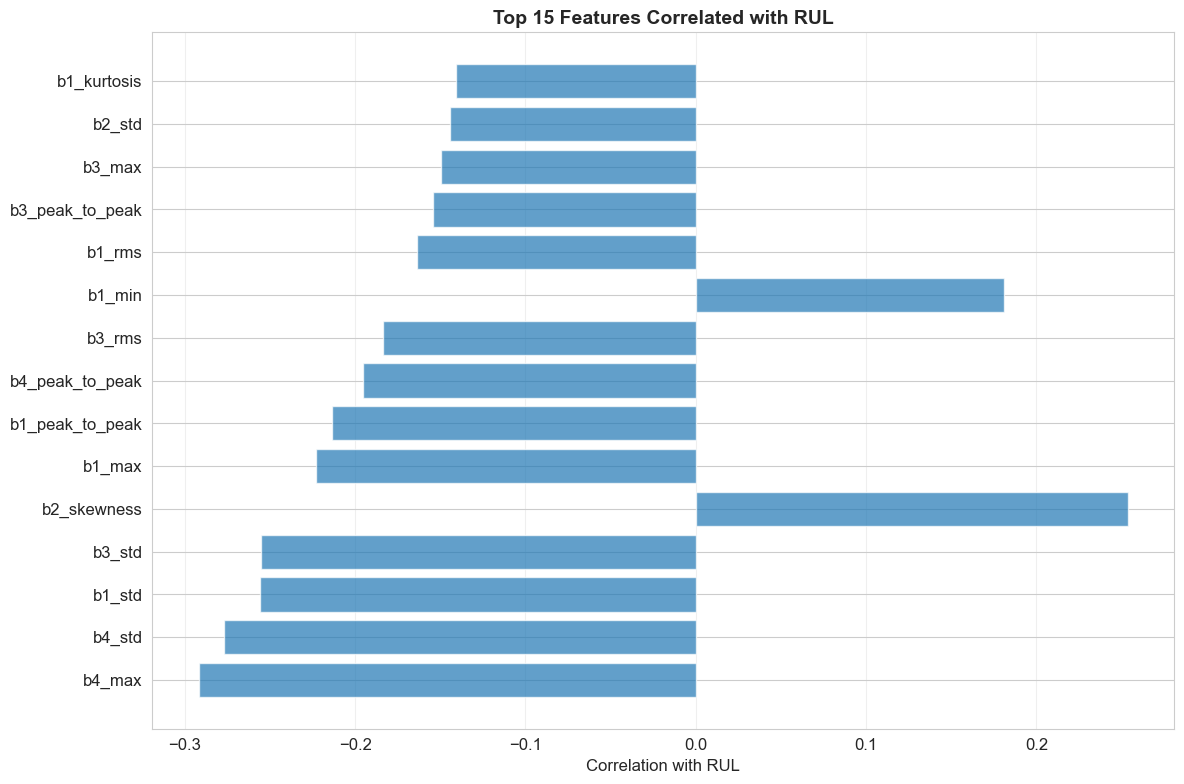

In [16]:
# Feature Correlation with RUL
import seaborn as sns

# Use the original features_df before sequence generation
feature_cols = [c for c in features_df.columns if c != 'RUL']
correlations = features_df[feature_cols].corrwith(features_df['RUL']).sort_values(ascending=False)
top_features = correlations.abs().nlargest(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_features)), correlations[top_features.index].values, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation with RUL')
plt.title('Top 15 Features Correlated with RUL', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Model Performance Visualizations


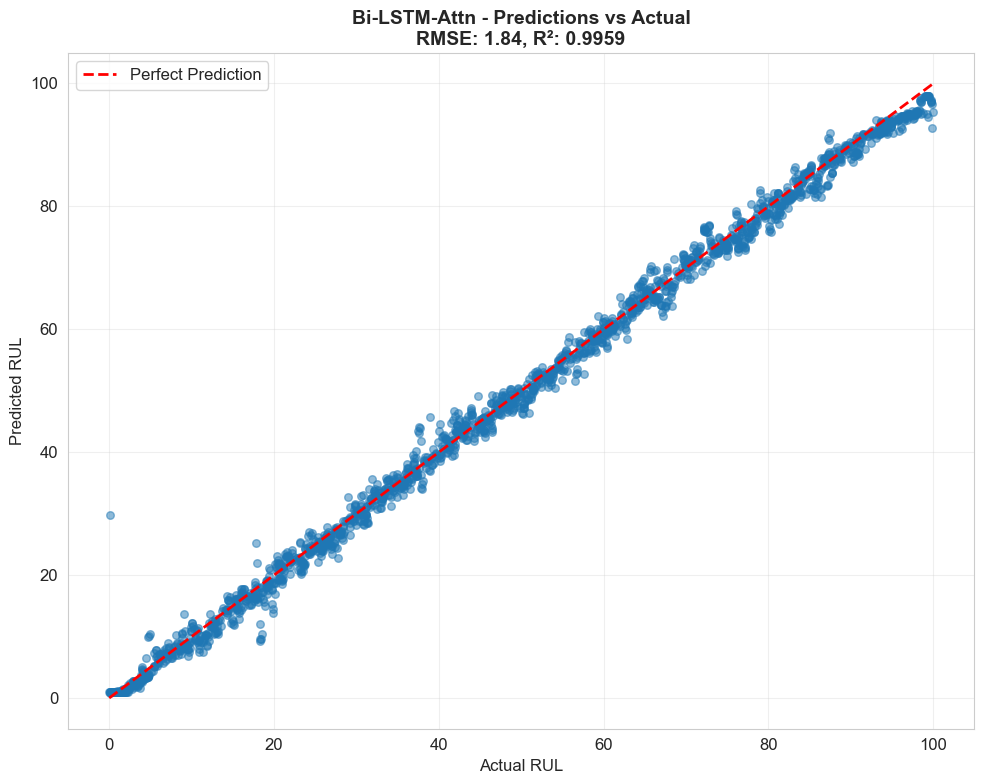

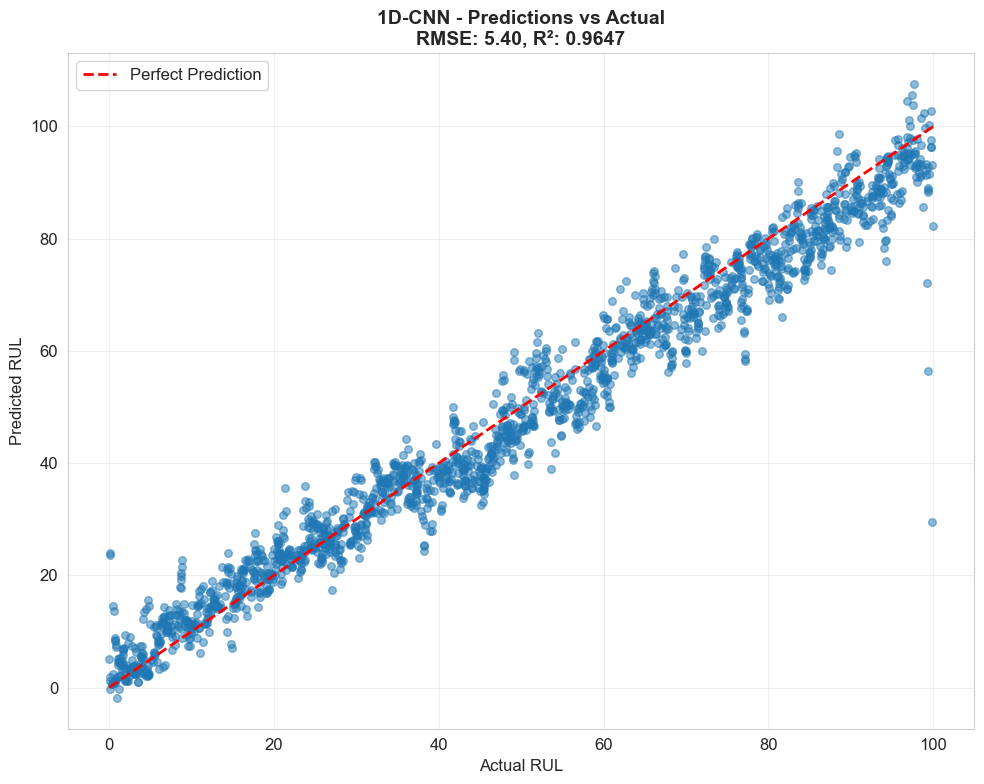

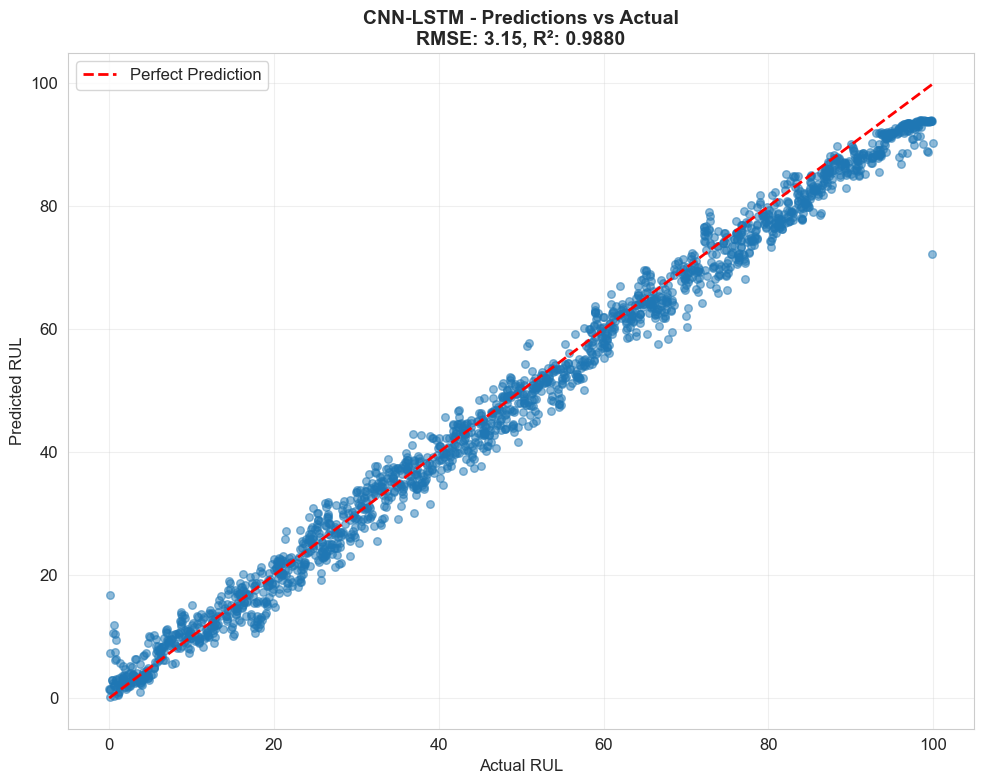

In [17]:
# Check if results exist
if 'results' not in locals():
    print("⚠️ Error: 'results' not defined. Please run the Training Cell (Cell 12) first!")
else:
    # Individual Model: Predictions vs Actual
    for model_name in results.keys():
        y_pred = results[model_name]['Predictions']
        
        plt.figure(figsize=(10, 8))
        plt.scatter(y_test, y_pred, alpha=0.5, s=30)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', lw=2, label='Perfect Prediction')
        plt.title(f'{model_name} - Predictions vs Actual\nRMSE: {results[model_name]["RMSE"]:.2f}, R²: {results[model_name]["R2"]:.4f}', 
                  fontsize=14, fontweight='bold')
        plt.xlabel('Actual RUL')
        plt.ylabel('Predicted RUL')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

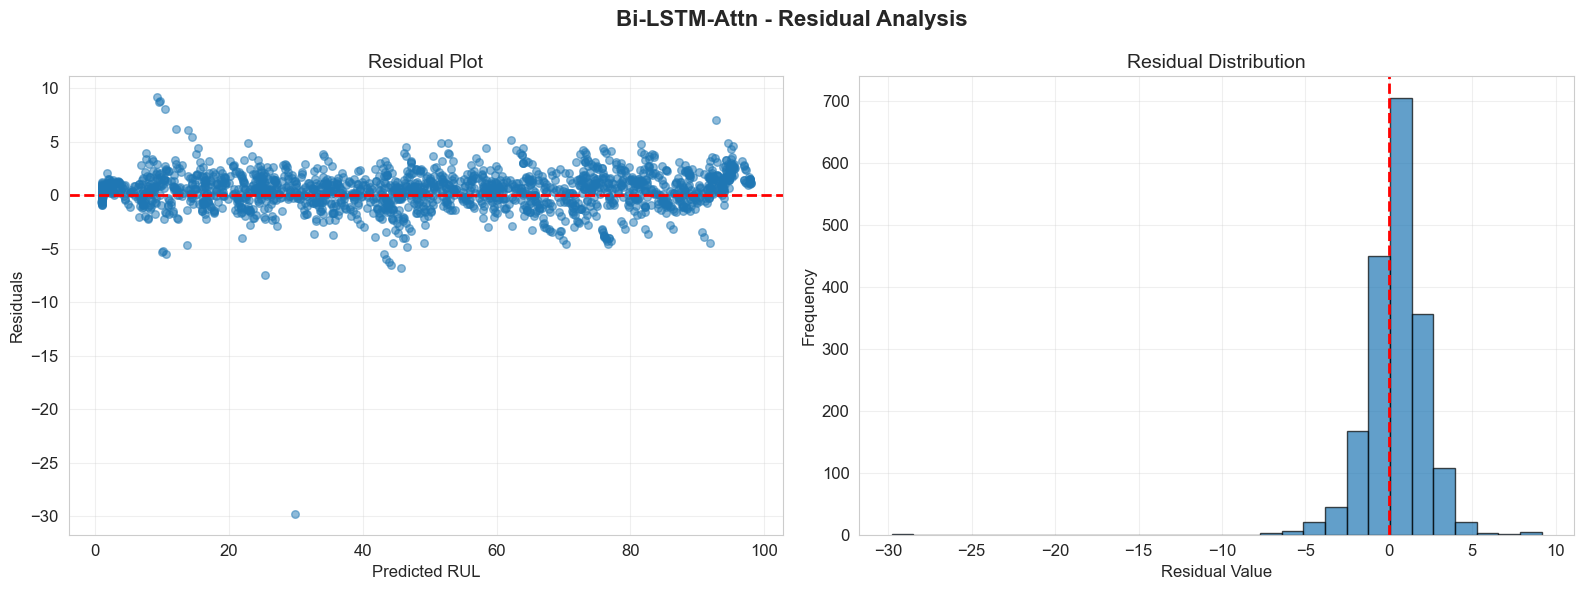

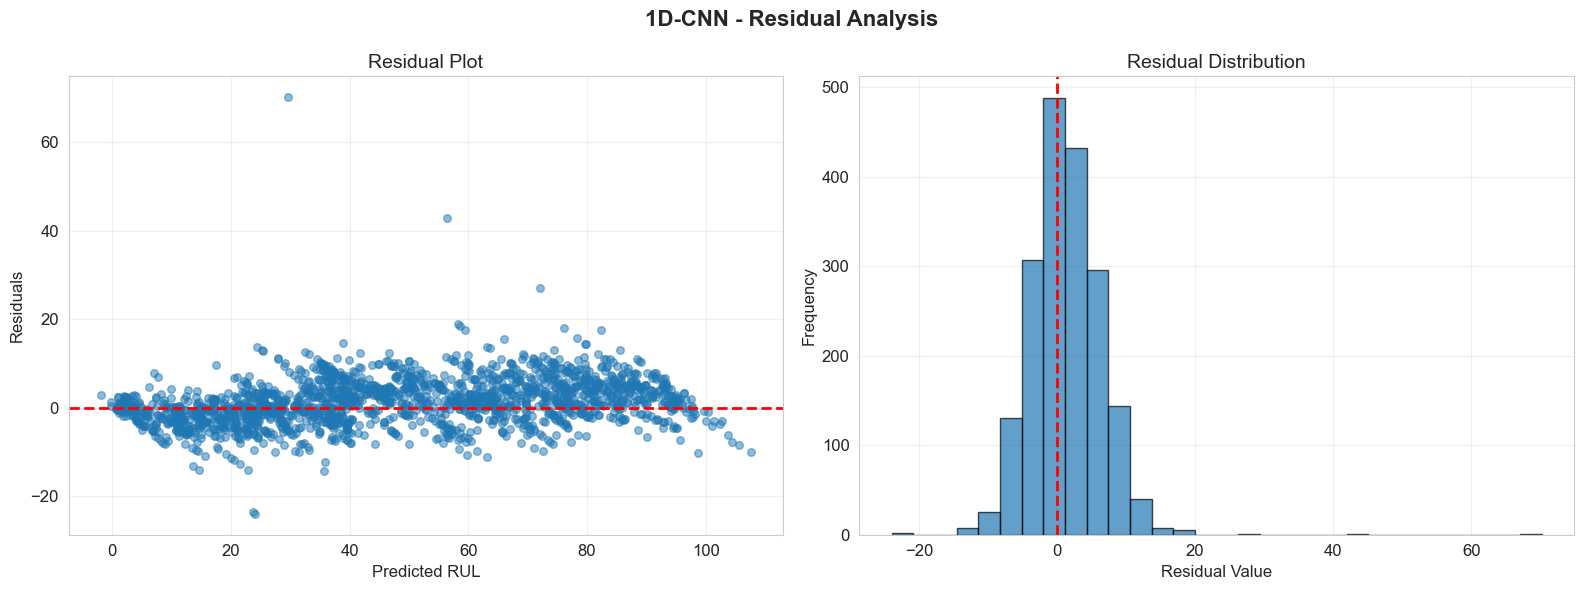

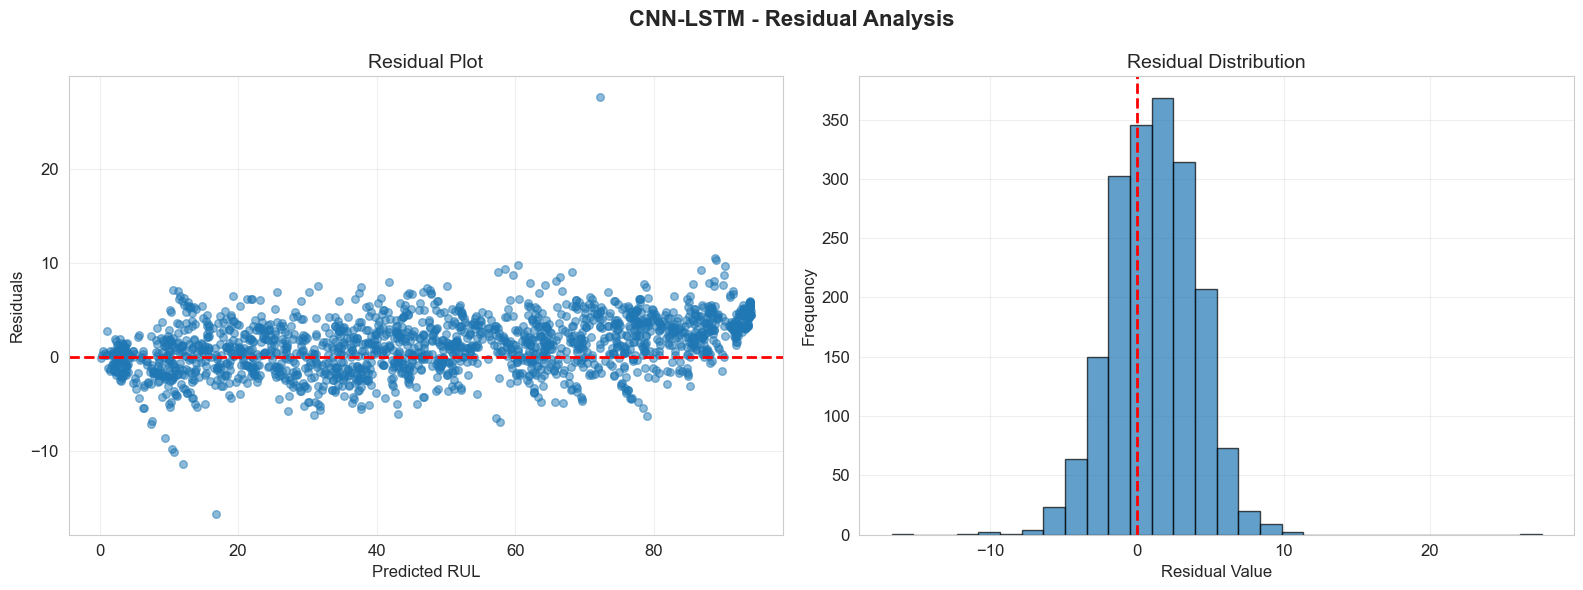

In [18]:
# Check if results exist
if 'results' not in locals():
    print("⚠️ Error: 'results' not defined. Please run the Training Cell (Cell 12) first!")
else:
    # Individual Model: Residual Analysis
    for model_name in results.keys():
        y_pred = results[model_name]['Predictions']
        residuals = y_test - y_pred
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'{model_name} - Residual Analysis', fontsize=16, fontweight='bold')
        
        # Residual scatter
        axes[0].scatter(y_pred, residuals, alpha=0.5, s=30)
        axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[0].set_title('Residual Plot')
        axes[0].set_xlabel('Predicted RUL')
        axes[0].set_ylabel('Residuals')
        axes[0].grid(True, alpha=0.3)
        
        # Residual distribution
        axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
        axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
        axes[1].set_title('Residual Distribution')
        axes[1].set_xlabel('Residual Value')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

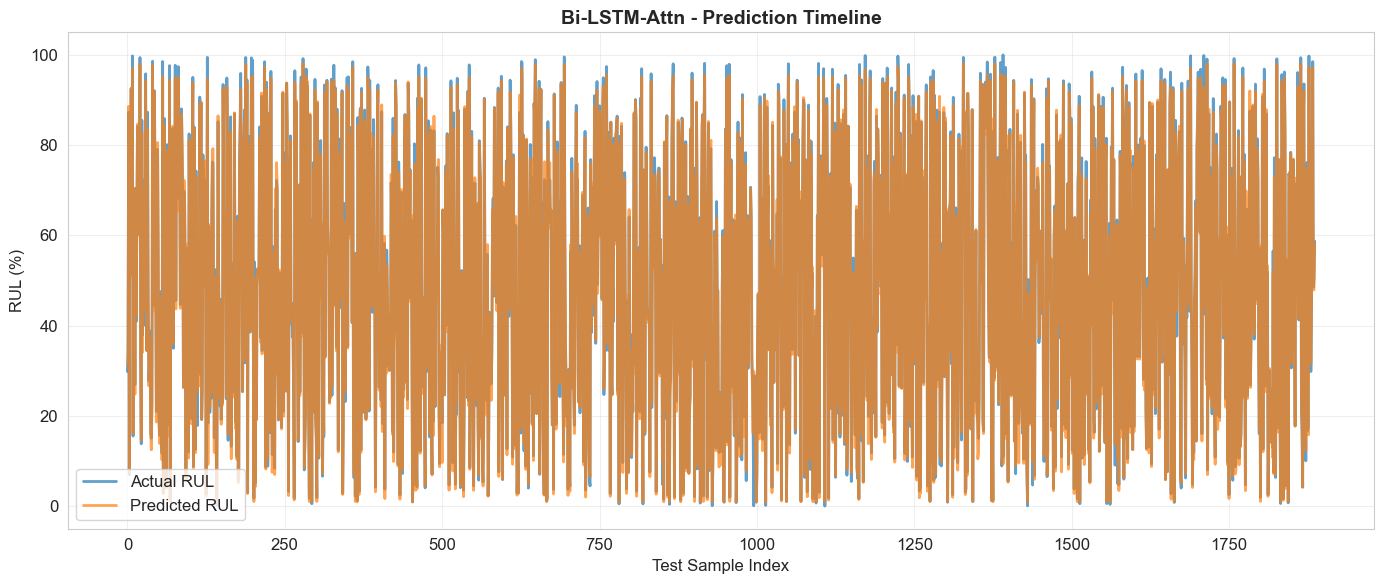

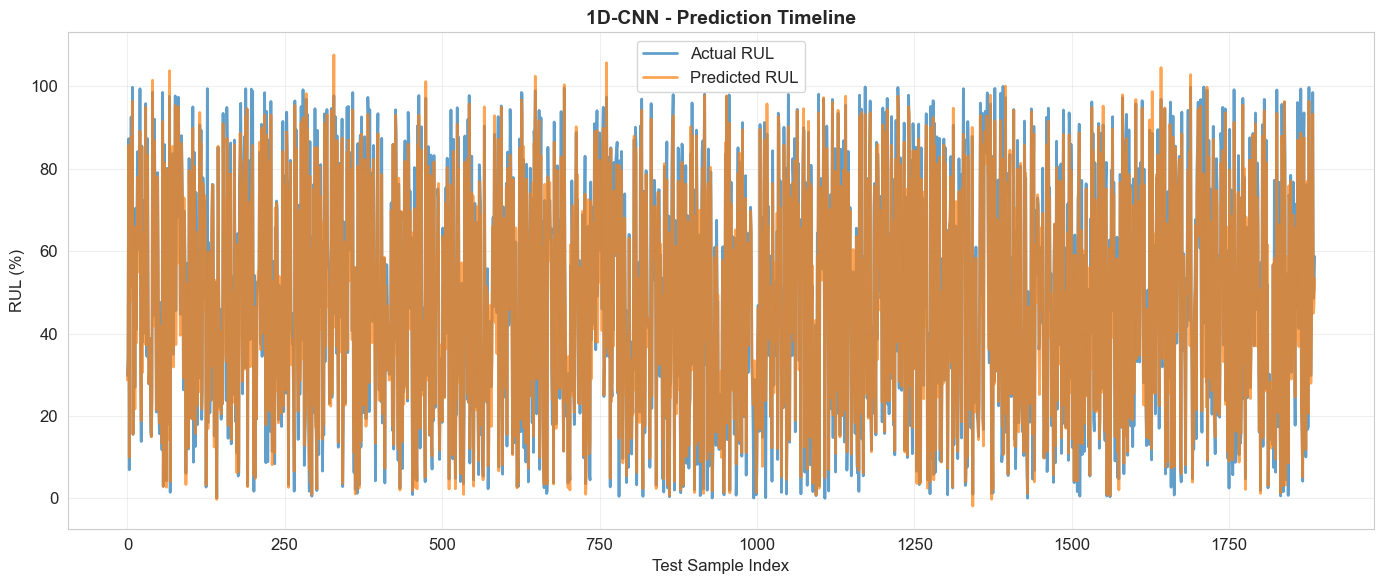

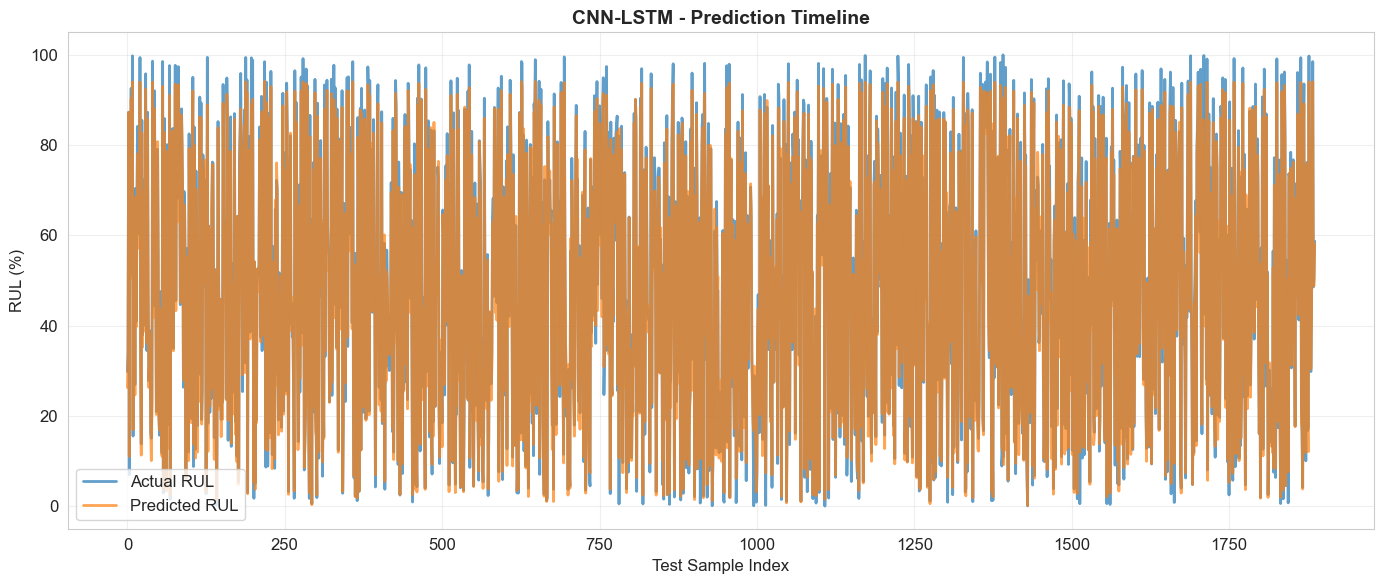

In [19]:
# Check if results exist
if 'results' not in locals():
    print("⚠️ Error: 'results' not defined. Please run the Training Cell (Cell 12) first!")
else:
    # Individual Model: Prediction Timeline
    for model_name in results.keys():
        y_pred = results[model_name]['Predictions']
        
        plt.figure(figsize=(14, 6))
        plt.plot(y_test, label='Actual RUL', linewidth=2, alpha=0.7)
        plt.plot(y_pred, label='Predicted RUL', linewidth=2, alpha=0.7)
        plt.fill_between(range(len(y_test)), y_test, y_pred, alpha=0.2)
        plt.title(f'{model_name} - Prediction Timeline', fontsize=14, fontweight='bold')
        plt.xlabel('Test Sample Index')
        plt.ylabel('RUL (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 7. Save Models and Artifacts

We save the trained models, scalers, and metrics to the `models` directory for future use.

In [20]:
import joblib
import json
from datetime import datetime

# Create base models directory if it doesn't exist
MODELS_DIR = os.path.abspath(os.path.join('..', 'Trained_models', 'nasa_dl_comparison'))
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Saving models to: {MODELS_DIR}")

for name, model in models.items():
    # Clean name for filesystem (e.g., 'Bi-LSTM' -> 'Bi-LSTM')
    clean_name = name.replace(' ', '_')
    
    # Create specific folder for this model type
    model_dir = os.path.join(MODELS_DIR, clean_name)
    os.makedirs(model_dir, exist_ok=True)
    
    # 1. Save Keras Model with Descriptive Name
    # e.g., Bi-LSTM_model.keras
    model_filename = f"{clean_name}_model.keras"
    model_path = os.path.join(model_dir, model_filename)
    model.save(model_path)
    
    # 2. Save Scaler with Descriptive Name
    # e.g., Bi-LSTM_scaler.pkl
    scaler_filename = f"{clean_name}_scaler.pkl"
    scaler_path = os.path.join(model_dir, scaler_filename)
    joblib.dump(scaler, scaler_path)
    
    # 3. Save Metadata (Metrics & Config)
    metadata = {
        'model_name': name,
        'filename': model_filename,
        'scaler_filename': scaler_filename,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'metrics': {
            'RMSE': float(results[name]['RMSE']),
            'MAE': float(results[name]['MAE']),
            'R2': float(results[name]['R2'])
        },
        'input_shape': input_shape,
        'window_size': WINDOW_SIZE
    }
    
    metadata_path = os.path.join(model_dir, f"{clean_name}_metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
        
    print(f"  ✓ Saved {name} artifacts to {model_dir}")
    print(f"    - Model: {model_filename}")
    print(f"    - Scaler: {scaler_filename}")

Saving models to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\models\nasa_dl_comparison
  ✓ Saved Bi-LSTM-Attn artifacts to d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\models\nasa_dl_comparison\Bi-LSTM-Attn
    - Model: Bi-LSTM-Attn_model.keras
    - Scaler: Bi-LSTM-Attn_scaler.pkl
  ✓ Saved 1D-CNN artifacts to d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\models\nasa_dl_comparison\1D-CNN
    - Model: 1D-CNN_model.keras
    - Scaler: 1D-CNN_scaler.pkl
  ✓ Saved CNN-LSTM artifacts to d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\models\nasa_dl_comparison\CNN-LSTM
    - Model: CNN-LSTM_model.keras
    - Scaler: CNN-LSTM_scaler.pkl


## 8. Compare with ML Models

We compare our Deep Learning models with the best performing Machine Learning model from the previous stage.

Best ML Model: SVR
  RMSE: 40.1333
  MAE:  39.4215
  R2:   -20.5711


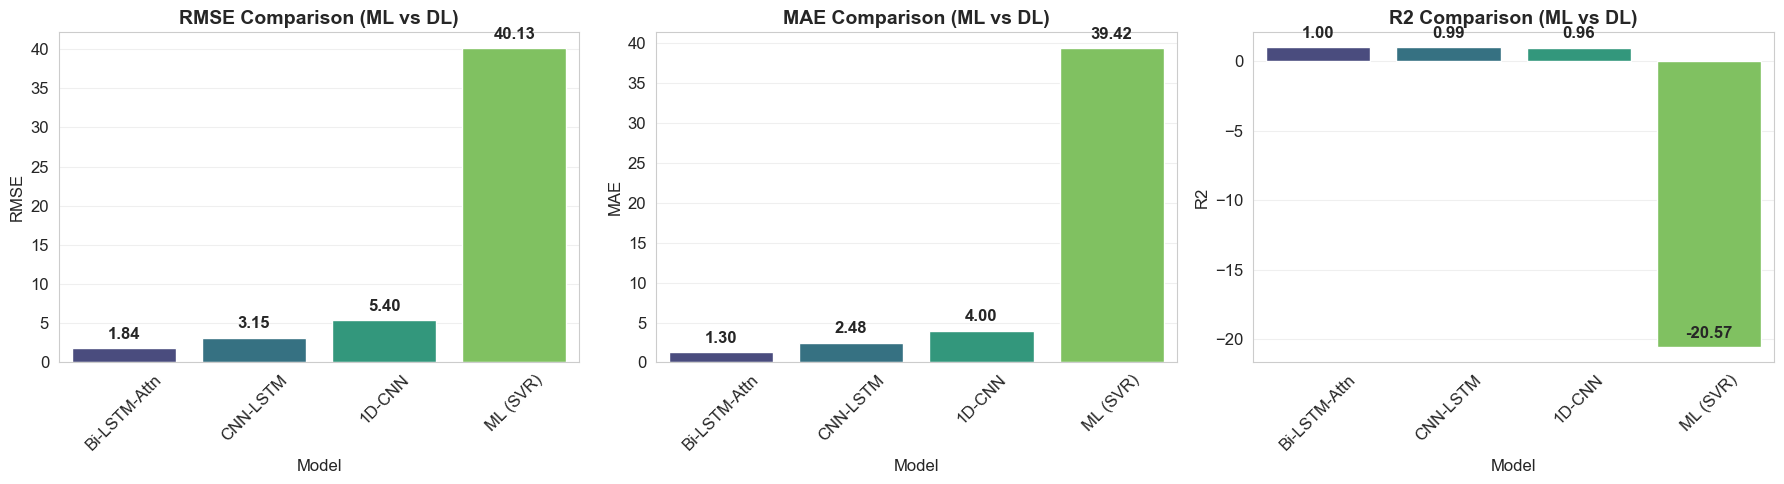

In [21]:
# Load ML Metadata
ml_metadata_path = os.path.abspath(os.path.join('..', 'Trained_models', 'nasa_ml', 'metadata.json'))

if os.path.exists(ml_metadata_path):
    with open(ml_metadata_path, 'r') as f:
        ml_metadata = json.load(f)
    
    best_ml_model = ml_metadata['best_model']
    best_ml_rmse = ml_metadata['best_rmse']
    best_ml_r2 = ml_metadata['best_r2']
    
    # We need MAE too, let's try to get it from test_results if available
    # The structure is test_results -> MAE -> ModelName
    best_ml_mae = ml_metadata['test_results']['MAE'][best_ml_model]
    
    print(f"Best ML Model: {best_ml_model}")
    print(f"  RMSE: {best_ml_rmse:.4f}")
    print(f"  MAE:  {best_ml_mae:.4f}")
    print(f"  R2:   {best_ml_r2:.4f}")
    
    # Add ML to results for comparison
    results[f'ML ({best_ml_model})'] = {
        'RMSE': best_ml_rmse,
        'MAE': best_ml_mae,
        'R2': best_ml_r2
    }
    
    # Re-plot Comparison
    metrics_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R2']]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['RMSE', 'MAE', 'R2']
    colors = ['#FF9999', '#66B2FF', '#99FF99']
    
    for i, metric in enumerate(metrics):
        # Sort for better visualization
        if metric == 'R2':
            sorted_df = metrics_df.sort_values(metric, ascending=False)
        else:
            sorted_df = metrics_df.sort_values(metric, ascending=True)
            
        sns.barplot(x=sorted_df.index, y=sorted_df[metric], ax=axes[i], palette='viridis')
        axes[i].set_title(f'{metric} Comparison (ML vs DL)', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Model', fontsize=12)
        axes[i].set_ylabel(metric, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add values
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("ML metadata not found. Run 02_NASA_ML_training.ipynb first.")

In [22]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

print("\n2. Test Set Performance (Generalization):")
print("="*95)
print(f"{'Model':<15} | {'RMSE (%)':<10} | {'MAE (%)':<10} | {'R² Score':<10} | {'Acc (<10%)':<12} ")
print("-"*95)

for name, metrics in results.items():
    # Handle missing predictions
    if 'Predictions' not in metrics and 'predictions' not in metrics and 'pred' not in metrics:
        print(f"⚠️ Warning: No predictions found for {name}. Keys: {list(metrics.keys())}")
        y_pred = np.zeros_like(y_test) # Dummy
    else:
        y_pred = metrics.get('Predictions', metrics.get('predictions', metrics.get('pred')))
        y_pred = y_pred.flatten()

    # Regression Metrics
    rmse = metrics['RMSE']
    mae = metrics['MAE']
    r2 = metrics['R2']
    
    # Accuracy (<10% Error)
    within_10 = np.abs(y_test - y_pred) <= 10
    acc_10 = np.mean(within_10) * 100
    
    print(f"{name:<15} | {rmse:<10.2f} | {mae:<10.2f} | {r2:<10.4f} | {acc_10:<12.1f} %")
print("="*95)



2. Test Set Performance (Generalization):
Model           | RMSE (%)   | MAE (%)    | R² Score   | Acc (<10%)   
-----------------------------------------------------------------------------------------------
Bi-LSTM-Attn    | 1.84       | 1.30       | 0.9959     | 99.9         %
1D-CNN          | 5.40       | 4.00       | 0.9647     | 95.2         %
CNN-LSTM        | 3.15       | 2.48       | 0.9880     | 99.7         %
⚠️ Warning: No predictions found for ML (SVR). Keys: ['RMSE', 'MAE', 'R2']
ML (SVR)        | 40.13      | 39.42      | -20.5711   | 10.7         %


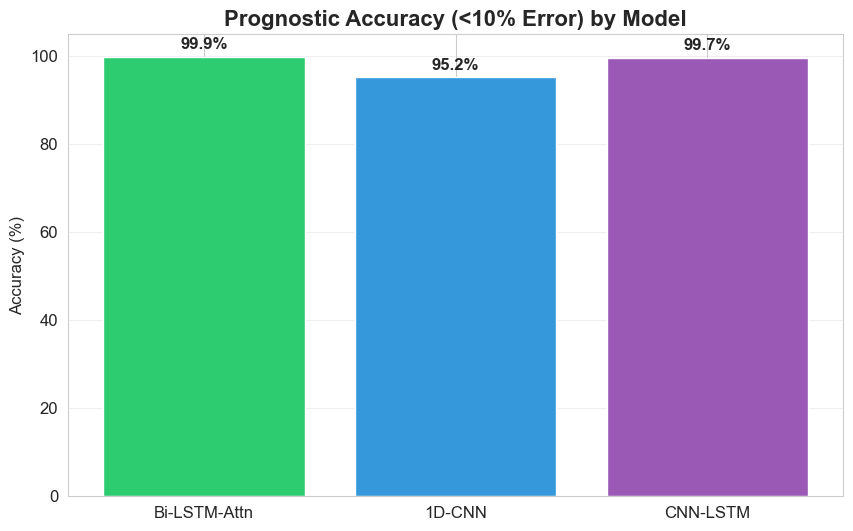

In [23]:
# ============================================
# PLOT ACCURACY PER MODEL
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_names = []
accuracies = []

for name, metrics in results.items():
    if 'Predictions' in metrics or 'predictions' in metrics or 'pred' in metrics:
        y_pred = metrics.get('Predictions', metrics.get('predictions', metrics.get('pred'))).flatten()
        # Accuracy (<10% Error)
        within_10 = np.abs(y_test - y_pred) <= 10
        acc = np.mean(within_10) * 100
        model_names.append(name)
        accuracies.append(acc)

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])

plt.title('Prognostic Accuracy (<10% Error) by Model', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

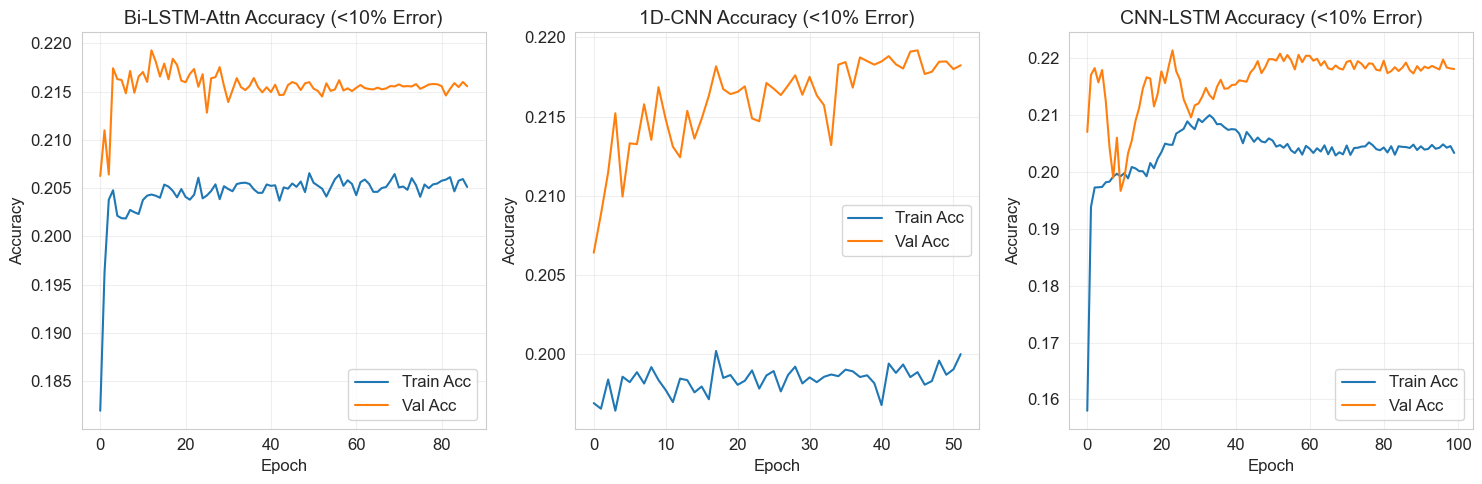

In [24]:
# ============================================
# PLOT TRAINING vs VALIDATION ACCURACY
# ============================================
plt.figure(figsize=(15, 5))

for i, (name, history) in enumerate(histories.items()):
    plt.subplot(1, 3, i+1)
    plt.plot(history.history['accuracy_10_percent'], label='Train Acc')
    plt.plot(history.history['val_accuracy_10_percent'], label='Val Acc')
    plt.title(f'{name} Accuracy (<10% Error)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()